# Network Traffic Flowlet Analysis
Visualizations of the MongoDB `networks_project.captures` collection. Each capture stores flowlets parsed at different inter-packet-time thresholds (0.05 s, 0.1 s, 0.2 s).

In [2]:
import re, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="crest")

# ── Find the newest snapshot under data-pipeline/data/snapshots ──
snapshots_root = Path("../data-pipeline/data/snapshots")
snapshot_dirs = sorted(snapshots_root.glob("snapshot_*"), reverse=True)
if not snapshot_dirs:
    raise FileNotFoundError(f"No snapshots found in {snapshots_root.resolve()}")
snapshot_dir = snapshot_dirs[0]
captures_dir = snapshot_dir / "captures"
print(f"Using snapshot: {snapshot_dir.name}")

# ── Load every capture JSON and flatten flowlets into one DataFrame ──
rows = []
capture_files = list(captures_dir.glob("*.json"))
for fpath in capture_files:
    with open(fpath, "r", encoding="utf-8") as f:
        doc = json.load(f)

    cap_id = str(doc.get("_id", fpath.stem))
    file_path = doc.get("file_path", cap_id)

    m = re.search(r"_(\d+\.?\d*)$", file_path)
    threshold = float(m.group(1)) if m else None
    base_name = file_path[:m.start()] if m else file_path

    for fl in doc.get("flowlets") or []:
        fk = fl.get("flow_key", {})
        rows.append({
            "capture_id":   cap_id,
            "base_capture":  base_name,
            "threshold":     threshold,
            "file_path":     file_path,
            "traffic_class": fl.get("traffic_class"),
            "llm_name":      fl.get("llm_name"),
            "outgoing":      fl.get("outgoing"),
            "direction_encoded": fl.get("direction_encoded", 0),
            "flowlet_id":    fl.get("flowlet_id"),
            "duration":      fl.get("duration", 0),
            "packet_count":  fl.get("packet_count", 0),
            "total_bytes":   fl.get("total_bytes", 0),
            "packet_size_mean": fl.get("packet_size_mean"),
            "packet_size_std":  fl.get("packet_size_std"),
            "inter_packet_time_mean": fl.get("inter_packet_time_mean"),
            "inter_packet_time_std":  fl.get("inter_packet_time_std"),
            "model_llm_prediction":   fl.get("model_llm_prediction"),
            "model_llm_confidence":   fl.get("model_llm_confidence"),
            "ground_truth_llm":       fl.get("ground_truth_llm"),
            "src_ip":   fk.get("src_ip"),
            "dst_ip":   fk.get("dst_ip"),
            "protocol": fk.get("protocol"),
        })

df = pd.DataFrame(rows)
print(f"Loaded {len(df):,} flowlets from {len(capture_files)} captures")
df.head()

Using snapshot: snapshot_20260407_121901
Loaded 465,375 flowlets from 93 captures


,capture_id,base_capture,threshold,file_path,traffic_class,llm_name,outgoing,direction_encoded,flowlet_id,duration,...,packet_size_mean,packet_size_std,inter_packet_time_mean,inter_packet_time_std,model_llm_prediction,model_llm_confidence,ground_truth_llm,src_ip,dst_ip,protocol
0,3_14_26_non_llm_bot_0.2,3_14_26_non_llm_bot,0.2,3_14_26_non_llm_bot_0.2,non_llm,None,None,0,1,0.279360,...,398.250000,467.834105,0.025396,0.042866,None,None,None,10.0.0.129,98.124.193.103,6
1,3_14_26_non_llm_bot_0.2,3_14_26_non_llm_bot,0.2,3_14_26_non_llm_bot_0.2,non_llm,None,None,0,1,0.140401,...,513.695652,598.138585,0.006382,0.010215,None,None,None,10.0.0.129,162.247.243.29,6
2,3_14_26_non_llm_bot_0.2,3_14_26_non_llm_bot,0.2,3_14_26_non_llm_bot_0.2,non_llm,None,None,0,1,0.244221,...,563.235294,525.445945,0.015264,0.017368,None,None,None,10.0.0.129,34.149.203.119,17
3,3_14_26_non_llm_bot_0.2,3_14_26_non_llm_bot,0.2,3_14_26_non_llm_bot_0.2,non_llm,None,None,0,1,0.000000,...,671.000000,0.000000,0.000000,0.000000,None,None,None,10.0.0.14,224.0.0.251,17
4,3_14_26_non_llm_bot_0.2,3_14_26_non_llm_bot,0.2,3_14_26_non_llm_bot_0.2,non_llm,None,None,0,2,0.026215,...,574.500000,639.049555,0.008738,0.007884,None,None,None,10.0.0.129,162.247.243.29,6


## Dataset Overview

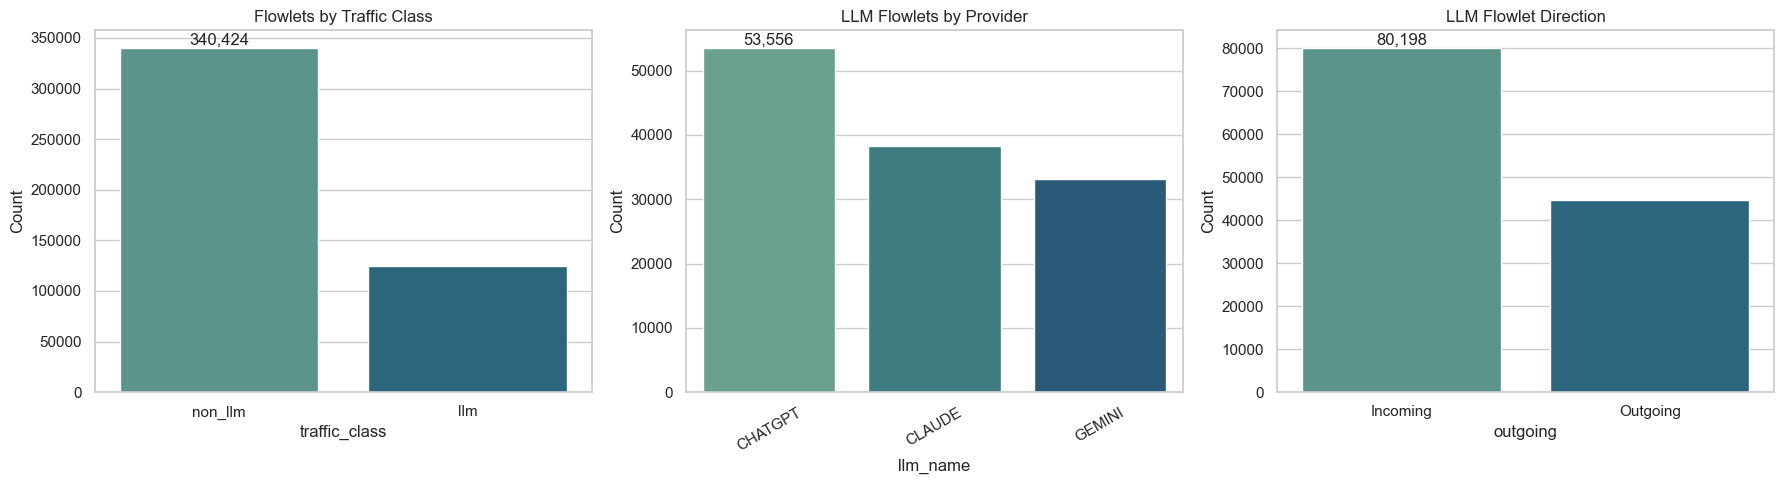

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 ── Traffic class split
class_counts = df["traffic_class"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette="crest", ax=axes[0])
axes[0].set_title("Flowlets by Traffic Class")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}")

# 2 ── LLM name breakdown (LLM flowlets only)
llm_df = df[df["traffic_class"] == "llm"]
if not llm_df.empty:
    llm_counts = llm_df["llm_name"].value_counts()
    sns.barplot(x=llm_counts.index, y=llm_counts.values, palette="crest", ax=axes[1])
    axes[1].set_title("LLM Flowlets by Provider")
    axes[1].set_ylabel("Count")
    axes[1].bar_label(axes[1].containers[0], fmt="{:,.0f}")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].set_title("LLM Flowlets by Provider (no data)")

# 3 ── Direction split for LLM traffic
if not llm_df.empty:
    dir_labels = llm_df["outgoing"].map({True: "Outgoing", False: "Incoming", None: "Unknown"})
    dir_counts = dir_labels.value_counts()
    sns.barplot(x=dir_counts.index, y=dir_counts.values, palette="crest", ax=axes[2])
    axes[2].set_title("LLM Flowlet Direction")
    axes[2].set_ylabel("Count")
    axes[2].bar_label(axes[2].containers[0], fmt="{:,.0f}")
else:
    axes[2].set_title("LLM Flowlet Direction (no data)")

plt.tight_layout()
plt.show()

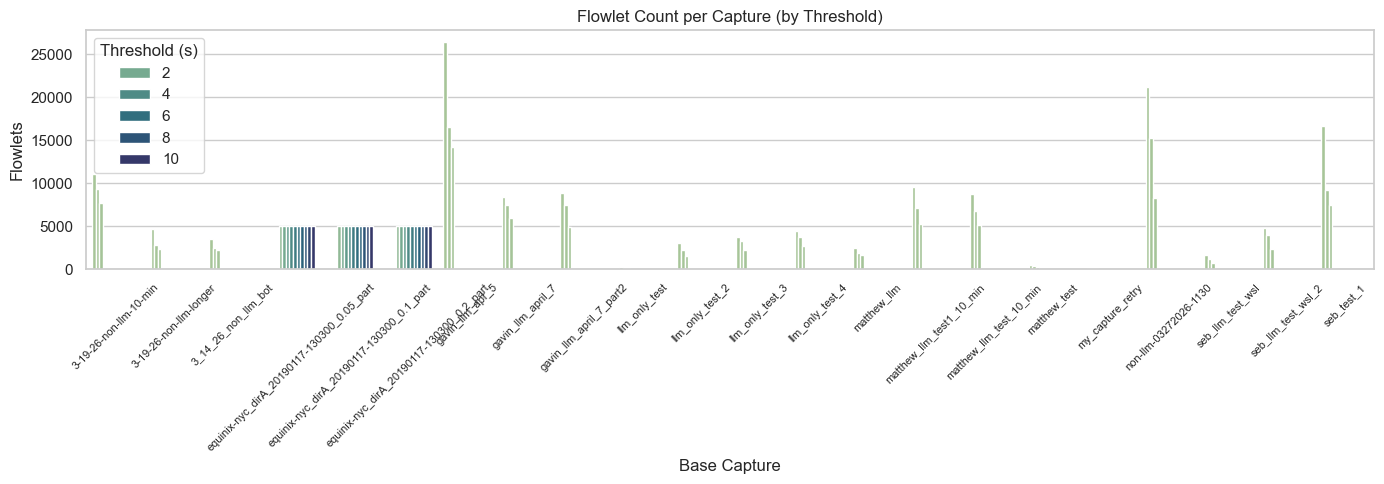

In [4]:
# Flowlets per base capture (grouped by threshold)
cap_counts = (
    df.groupby(["base_capture", "threshold"])
    .size()
    .reset_index(name="flowlet_count")
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(
    data=cap_counts, x="base_capture", y="flowlet_count",
    hue="threshold", palette="crest", ax=ax,
)
ax.set_title("Flowlet Count per Capture (by Threshold)")
ax.set_ylabel("Flowlets")
ax.set_xlabel("Base Capture")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(title="Threshold (s)")
plt.tight_layout()
plt.show()

## Threshold Impact Analysis
How does the inter-packet-time threshold affect flowlet characteristics? Captures are run at 0.05 s, 0.1 s, and 0.2 s — a larger threshold merges more packets into fewer, longer flowlets.

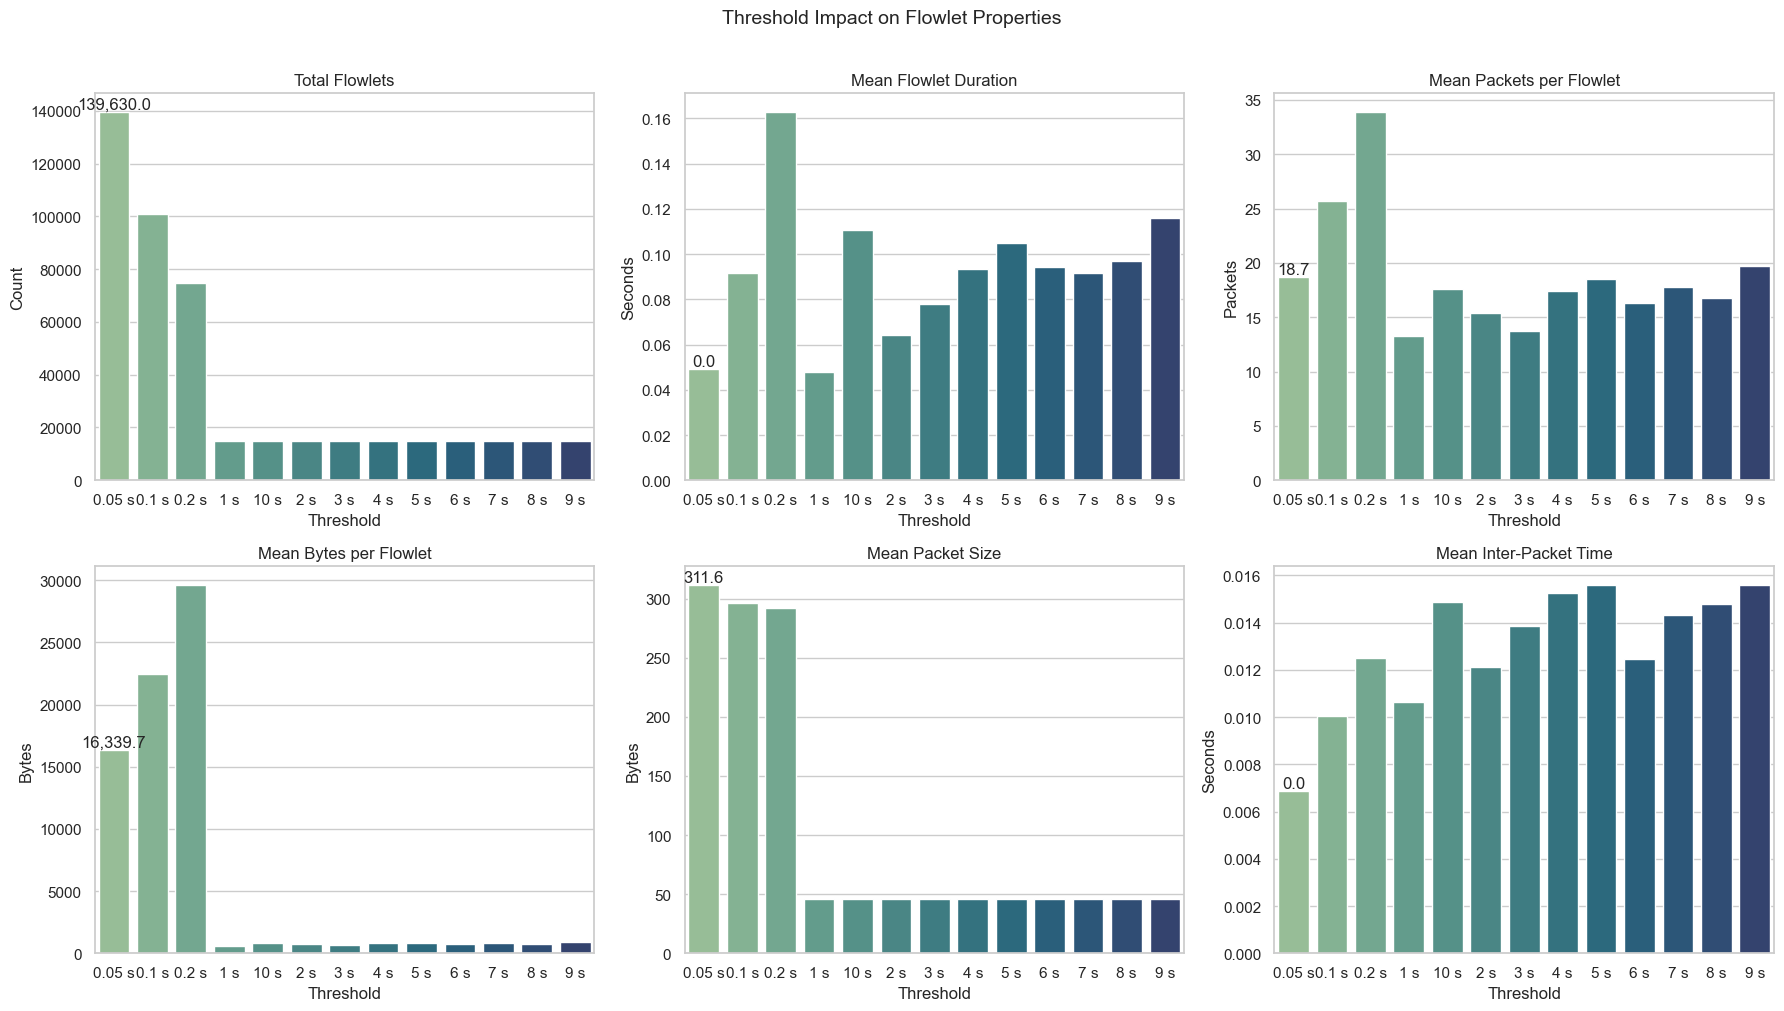

In [5]:
thr_df = df.dropna(subset=["threshold"]).copy()
thr_df["threshold_str"] = thr_df["threshold"].apply(lambda t: f"{t:g} s")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: aggregate stats per threshold
agg = (
    thr_df.groupby("threshold_str")
    .agg(
        flowlet_count=("flowlet_id", "count"),
        mean_duration=("duration", "mean"),
        mean_packet_count=("packet_count", "mean"),
        mean_total_bytes=("total_bytes", "mean"),
        mean_pkt_size=("packet_size_mean", "mean"),
        mean_ipt=("inter_packet_time_mean", "mean"),
    )
    .reset_index()
)

for ax, col, title, ylabel in zip(
    axes[0],
    ["flowlet_count", "mean_duration", "mean_packet_count"],
    ["Total Flowlets", "Mean Flowlet Duration", "Mean Packets per Flowlet"],
    ["Count", "Seconds", "Packets"],
):
    sns.barplot(data=agg, x="threshold_str", y=col, palette="crest", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Threshold")
    ax.bar_label(ax.containers[0], fmt="{:,.1f}")

for ax, col, title, ylabel in zip(
    axes[1],
    ["mean_total_bytes", "mean_pkt_size", "mean_ipt"],
    ["Mean Bytes per Flowlet", "Mean Packet Size", "Mean Inter-Packet Time"],
    ["Bytes", "Bytes", "Seconds"],
):
    sns.barplot(data=agg, x="threshold_str", y=col, palette="crest", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Threshold")
    ax.bar_label(ax.containers[0], fmt="{:,.1f}")

plt.suptitle("Threshold Impact on Flowlet Properties", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

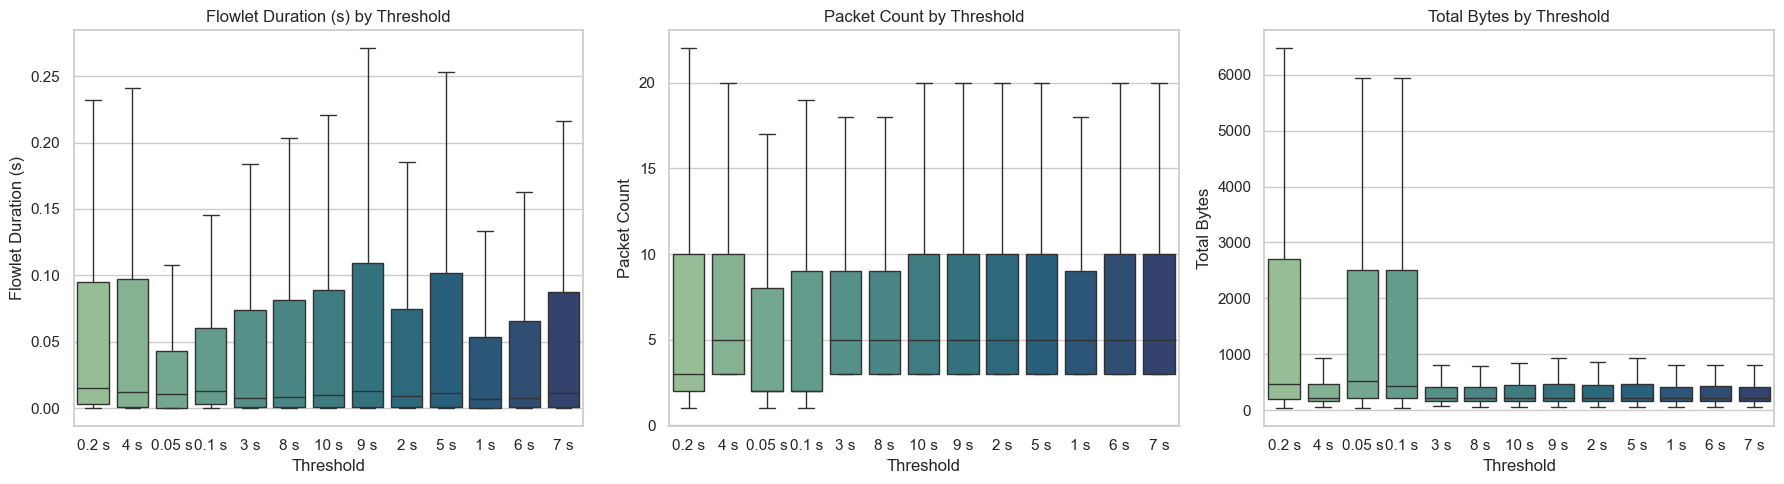

In [6]:
# Distribution shifts: how threshold changes the shape of key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ["duration", "packet_count", "total_bytes"],
    ["Flowlet Duration (s)", "Packet Count", "Total Bytes"],
):
    sns.boxplot(
        data=thr_df, x="threshold_str", y=col,
        palette="crest", showfliers=False, ax=ax,
    )
    ax.set_title(f"{title} by Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(title)

plt.tight_layout()
plt.show()

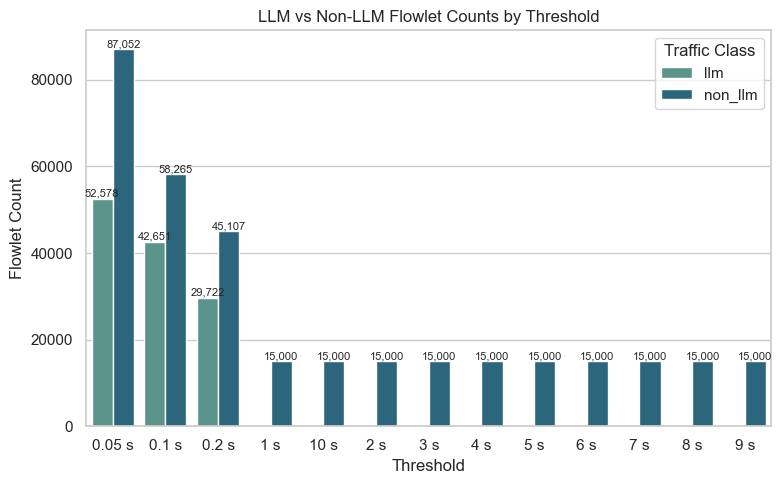

In [7]:
# LLM vs non-LLM flowlet counts across thresholds
class_thr = (
    thr_df.groupby(["threshold_str", "traffic_class"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=class_thr, x="threshold_str", y="count",
    hue="traffic_class", palette="crest", ax=ax,
)
ax.set_title("LLM vs Non-LLM Flowlet Counts by Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Flowlet Count")
ax.legend(title="Traffic Class")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=8)
plt.tight_layout()
plt.show()

## LLM vs Non-LLM Feature Distributions
Comparing the statistical signatures of LLM and non-LLM traffic.

/Users/taogroves/Library/Python/3.10/lib/python/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


ValueError: array must not contain infs or NaNs

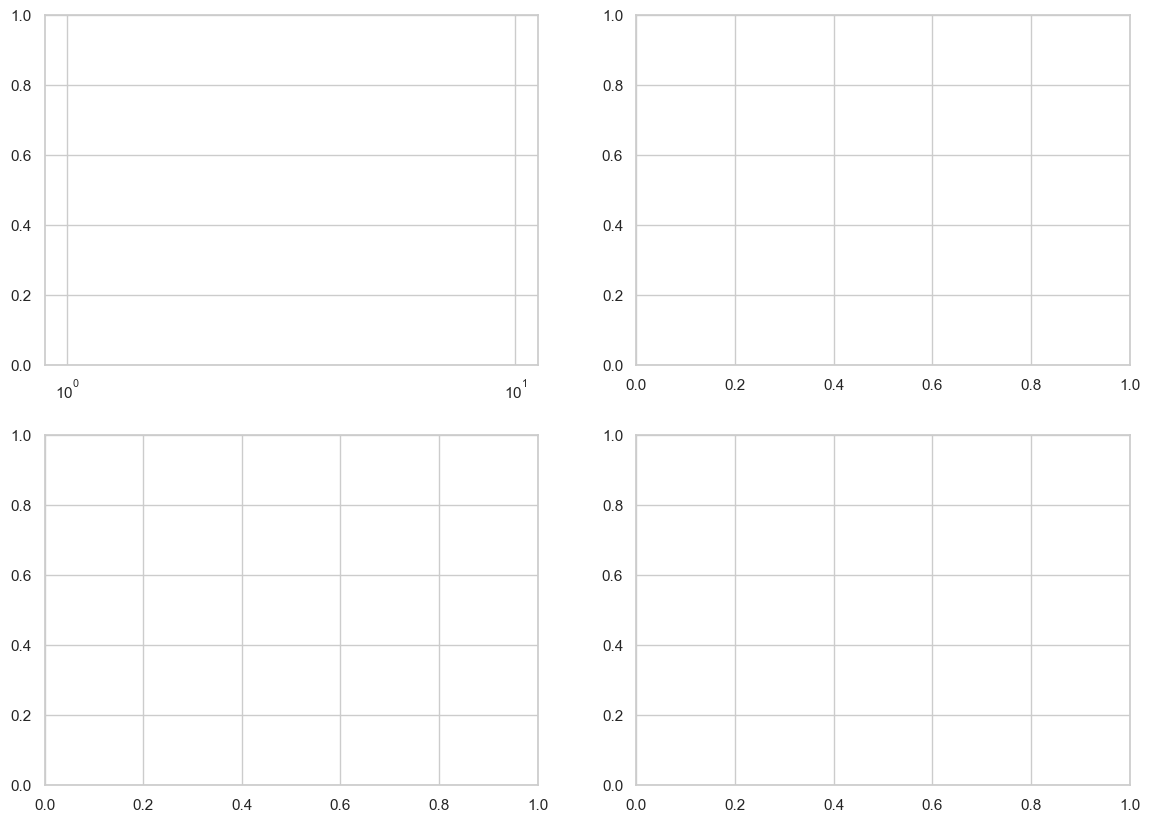

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = [
    ("duration", "Flowlet Duration (s)"),
    ("packet_count", "Packet Count"),
    ("total_bytes", "Total Bytes"),
    ("packet_size_mean", "Mean Packet Size (bytes)"),
]

for ax, (col, label) in zip(axes.flat, features):
    subset = df.dropna(subset=[col])
    sns.histplot(
        data=subset, x=col, hue="traffic_class",
        palette="crest", kde=True, stat="density",
        common_norm=False, ax=ax, log_scale=(True, False),
    )
    ax.set_title(f"{label} Distribution")
    ax.set_xlabel(label)

plt.suptitle("LLM vs Non-LLM Feature Distributions (log-scaled x)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

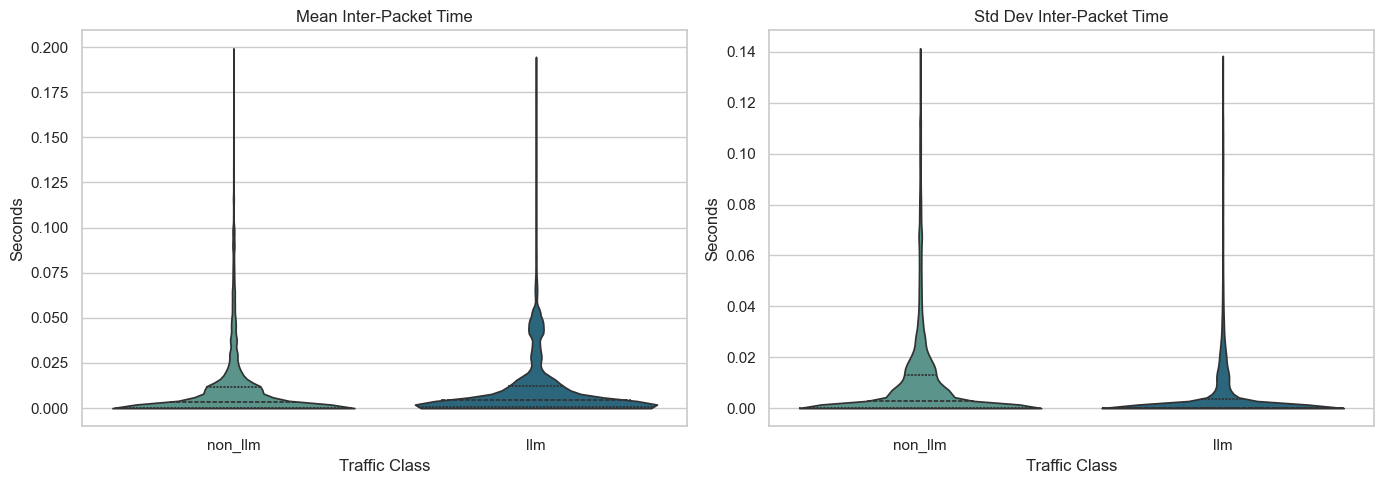

In [9]:
# Violin plots: inter-packet time statistics split by traffic class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["inter_packet_time_mean", "inter_packet_time_std"],
    ["Mean Inter-Packet Time", "Std Dev Inter-Packet Time"],
):
    subset = df.dropna(subset=[col])
    sns.violinplot(
        data=subset, x="traffic_class", y=col,
        palette="crest", inner="quartile", cut=0, ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("Seconds")
    ax.set_xlabel("Traffic Class")

plt.tight_layout()
plt.show()

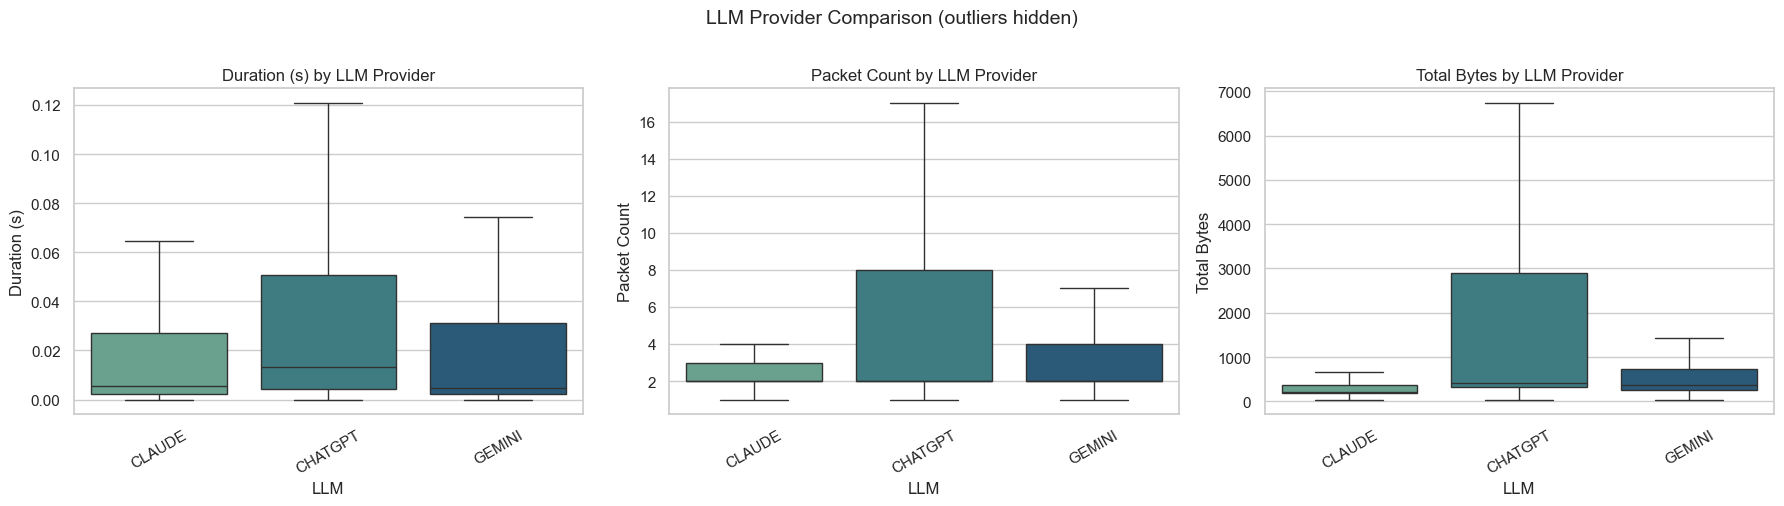

In [10]:
# Per-LLM provider comparison
if not llm_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, col, title in zip(
        axes,
        ["duration", "packet_count", "total_bytes"],
        ["Duration (s)", "Packet Count", "Total Bytes"],
    ):
        sns.boxplot(
            data=llm_df, x="llm_name", y=col,
            palette="crest", showfliers=False, ax=ax,
        )
        ax.set_title(f"{title} by LLM Provider")
        ax.set_xlabel("LLM")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("LLM Provider Comparison (outliers hidden)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No LLM flowlets to compare across providers.")

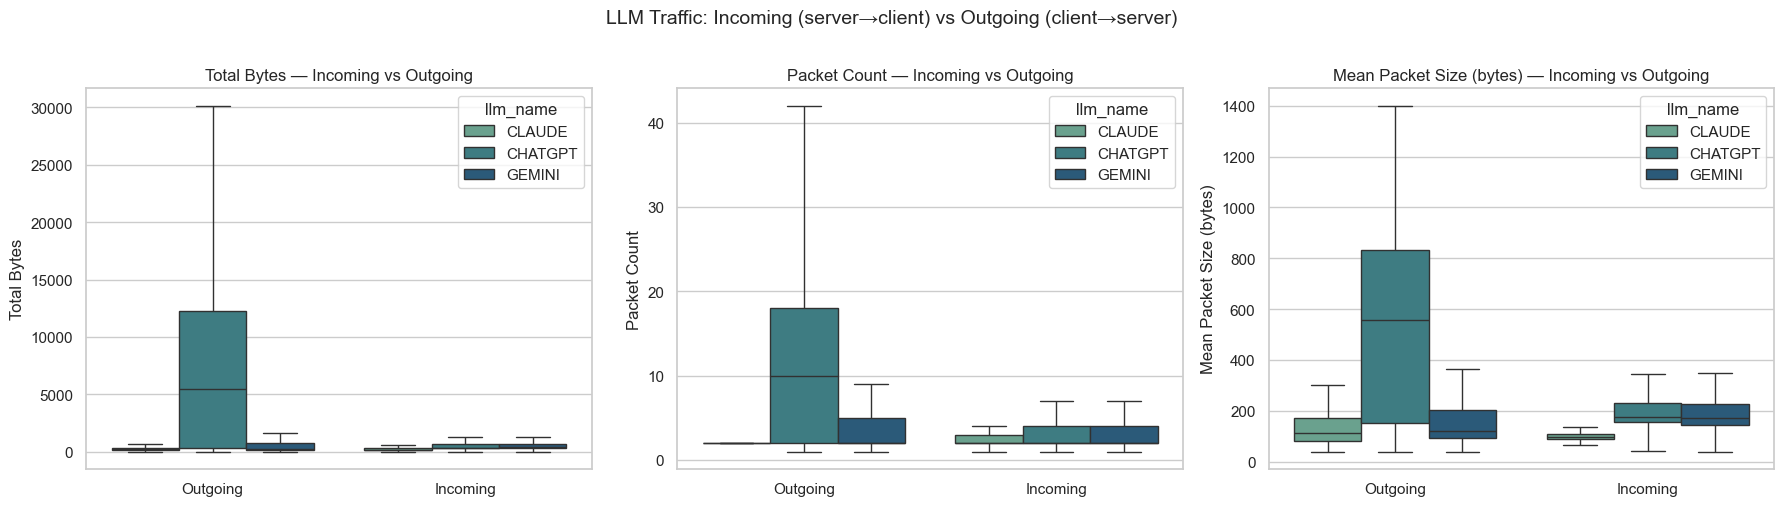

In [11]:
# Incoming vs outgoing LLM traffic characteristics
if not llm_df.empty:
    dir_df = llm_df.copy()
    dir_df["direction"] = dir_df["outgoing"].map({True: "Outgoing", False: "Incoming"})
    dir_df = dir_df.dropna(subset=["direction"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col, title in zip(
        axes,
        ["total_bytes", "packet_count", "packet_size_mean"],
        ["Total Bytes", "Packet Count", "Mean Packet Size (bytes)"],
    ):
        sns.boxplot(
            data=dir_df, x="direction", y=col,
            hue="llm_name", palette="crest", showfliers=False, ax=ax,
        )
        ax.set_title(f"{title} — Incoming vs Outgoing")
        ax.set_ylabel(title)
        ax.set_xlabel("")

    plt.suptitle("LLM Traffic: Incoming (server→client) vs Outgoing (client→server)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No LLM direction data.")

## Feature Correlations & Advanced Analysis

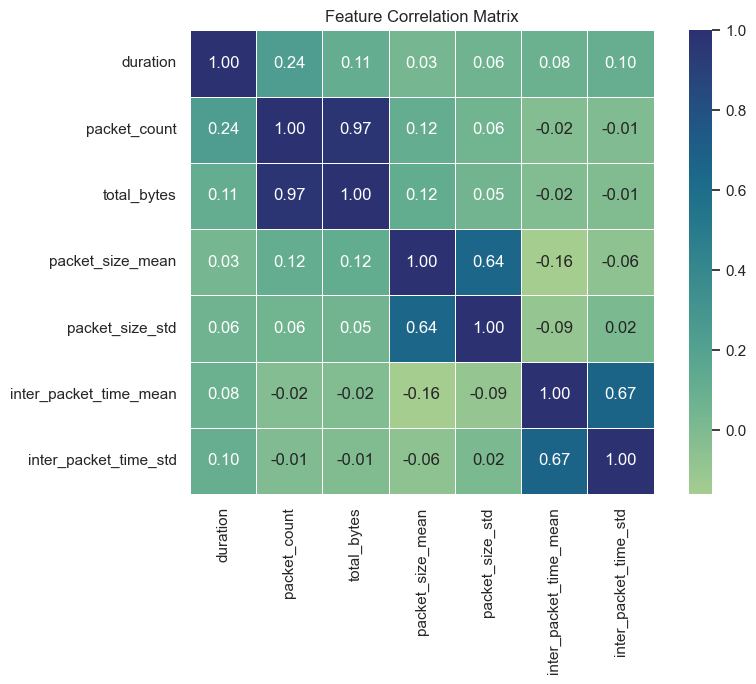

In [12]:
# Correlation heatmap of numeric flowlet features
numeric_cols = [
    "duration", "packet_count", "total_bytes",
    "packet_size_mean", "packet_size_std",
    "inter_packet_time_mean", "inter_packet_time_std",
]
corr = df[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="crest",
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

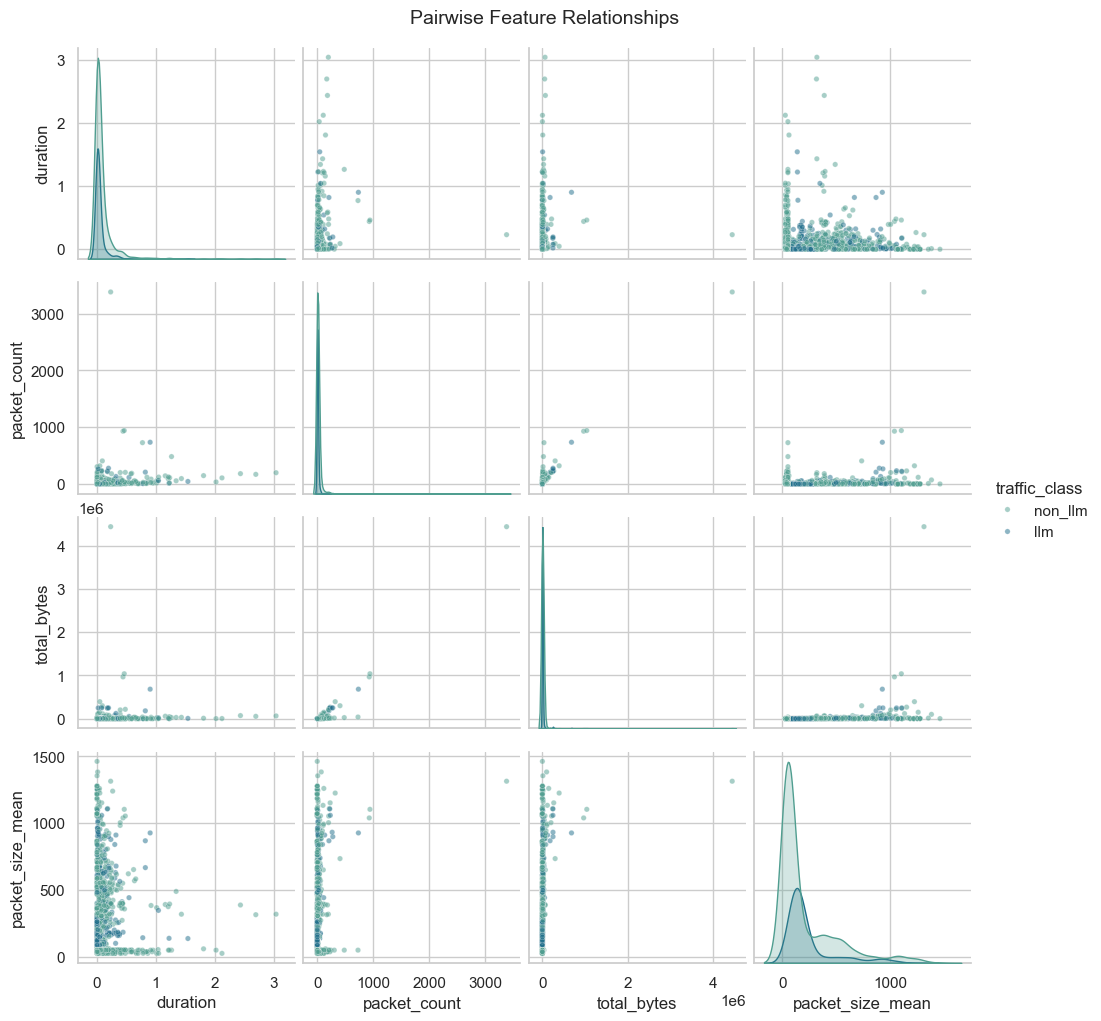

In [13]:
# Pairplot of key features coloured by traffic class (sampled for speed)
pair_cols = ["duration", "packet_count", "total_bytes", "packet_size_mean", "traffic_class"]
sample = df[pair_cols].dropna()
if len(sample) > 2000:
    sample = sample.sample(2000, random_state=42)

g = sns.pairplot(
    sample, hue="traffic_class",
    palette="crest", diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15},
)
g.figure.suptitle("Pairwise Feature Relationships", y=1.02, fontsize=14)
plt.show()

In [ ]:
# Bytes vs duration scatter — is LLM traffic more bursty or sustained?
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = df.dropna(subset=["duration", "total_bytes"])
if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42)

sns.scatterplot(
    data=plot_df, x="duration", y="total_bytes",
    hue="traffic_class", style="traffic_class",
    palette="crest", alpha=0.6, ax=ax,
)
ax.set_xscale("symlog", linthresh=0.01)
ax.set_yscale("symlog", linthresh=100)
ax.set_title("Total Bytes vs Duration")
ax.set_xlabel("Duration (s, symlog)")
ax.set_ylabel("Total Bytes (symlog)")
plt.tight_layout()
plt.show()

In [ ]:
# Protocol mix across traffic classes
proto_df = df.dropna(subset=["protocol"])
proto_counts = (
    proto_df.groupby(["traffic_class", "protocol"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=proto_counts, x="protocol", y="count",
    hue="traffic_class", palette="crest", ax=ax,
)
ax.set_title("Protocol Distribution by Traffic Class")
ax.set_ylabel("Flowlet Count")
ax.set_xlabel("IP Protocol Number")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Model prediction confidence distribution (where predictions exist)
pred_df = df.dropna(subset=["model_llm_confidence"])
if not pred_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        data=pred_df, x="model_llm_confidence", hue="traffic_class",
        palette="crest", kde=True, stat="density",
        common_norm=False, ax=axes[0],
    )
    axes[0].set_title("Model Confidence Distribution")
    axes[0].set_xlabel("Confidence")

    # Confusion-style: prediction vs ground truth
    gt_df = pred_df.dropna(subset=["ground_truth_llm"])
    if not gt_df.empty:
        gt_df = gt_df.copy()
        gt_df["correct"] = gt_df["model_llm_prediction"] == gt_df["ground_truth_llm"]
        sns.histplot(
            data=gt_df, x="model_llm_confidence", hue="correct",
            palette="crest", kde=True, stat="density",
            common_norm=False, ax=axes[1],
        )
        axes[1].set_title("Confidence by Prediction Correctness")
        axes[1].set_xlabel("Confidence")
        axes[1].legend(title="Correct?")
    else:
        axes[1].text(0.5, 0.5, "No ground truth labels available",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Confidence by Correctness (no ground truth)")

    plt.tight_layout()
    plt.show()
else:
    print("No model predictions found in the database.")

In [ ]:
# Threshold effect on LLM-specific flowlets: do some LLMs split more than others?
if not llm_df.empty:
    llm_thr = thr_df[thr_df["traffic_class"] == "llm"]
    if not llm_thr.empty:
        llm_thr_counts = (
            llm_thr.groupby(["threshold_str", "llm_name"])
            .size()
            .reset_index(name="count")
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(
            data=llm_thr_counts, x="llm_name", y="count",
            hue="threshold_str", palette="crest", ax=ax,
        )
        ax.set_title("LLM Flowlet Count by Provider and Threshold")
        ax.set_ylabel("Flowlet Count")
        ax.set_xlabel("LLM Provider")
        ax.legend(title="Threshold (s)")
        for container in ax.containers:
            ax.bar_label(container, fmt="{:,.0f}", fontsize=7)
        plt.tight_layout()
        plt.show()
else:
    print("No LLM flowlets for threshold×provider analysis.")

In [ ]:
# Packet-size variability: std vs mean coloured by class
fig, ax = plt.subplots(figsize=(10, 6))
sz_df = df.dropna(subset=["packet_size_mean", "packet_size_std"])
if len(sz_df) > 3000:
    sz_df = sz_df.sample(3000, random_state=42)

sns.scatterplot(
    data=sz_df, x="packet_size_mean", y="packet_size_std",
    hue="traffic_class", palette="crest", alpha=0.5, ax=ax,
)
ax.set_title("Packet Size Variability (Std vs Mean)")
ax.set_xlabel("Mean Packet Size (bytes)")
ax.set_ylabel("Packet Size Std Dev (bytes)")
plt.tight_layout()
plt.show()

In [ ]:
print("Done — all visualizations rendered.")